In [42]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

In [43]:
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64)
svm_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge")),
    ]
)
svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [44]:
svm_clf.predict([[5.5,1.7]])

array([1.])

In [54]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

train_size = int(len(X) * 0.8)

polynomial_svm_clf = Pipeline(
    [
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=1, loss="hinge")),
    ]
)

polynomial_svm_clf.fit(X[:train_size], y[:train_size])

c:\Users\Haji Suleman\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=1, loss='hinge'))])

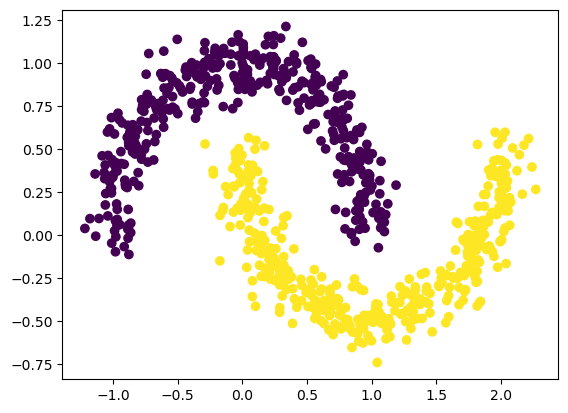

In [55]:
y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]
plt.scatter(x_tester[:, 0], x_tester[:, 1],c=y_predicted)

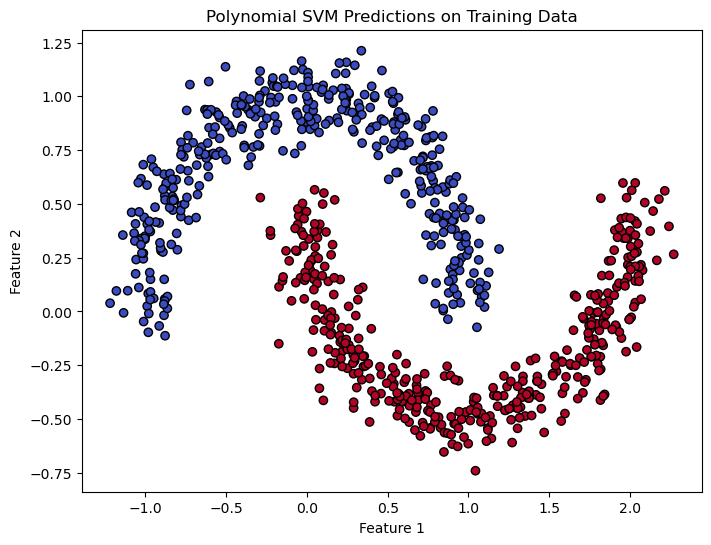

In [ ]:
import matplotlib.pyplot as plt

y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]

plt.figure(figsize=(8, 6))
plt.scatter(
    x_tester[:, 0], x_tester[:, 1], c=y_predicted, cmap="coolwarm", edgecolors="k"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Predictions on Training Data")
plt.savefig("coolwarm.png")
plt.show()